In [166]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt 
import importlib
import helpers
import statsmodels.api as sm
importlib.reload(helpers)

from helpers import data_extraction,montecarlosims, ConfigLoader,factor_models


# get the data of my portfolio 




IndentationError: expected an indented block after function definition on line 116 (helpers.py, line 117)

In [117]:
# read config file
config=ConfigLoader.configload()
config


{'stocks': ['PLTR',
  'AAPL',
  'MSFT',
  'NVDA',
  'BABA',
  'SOFI',
  'AVPT',
  'CRM',
  'GOOG',
  'DKNG',
  'LMT',
  'NOC',
  'NFLX',
  'PG',
  'UNH',
  'ADBE'],
 'weigths': [0.43,
  0.06,
  0.07,
  0.06,
  0.04,
  0.03,
  0.03,
  0.04,
  0.06,
  0.02,
  0.005,
  0.005,
  0.04,
  0.05,
  0.06,
  0.01]}

In [118]:
# get the data of my portfolio 
end=dt.datetime(year=2025,month=12,day=31)
start=dt.datetime(year=2021,month=1,day=1)
returns,meanReturns,Covmatrix=data_extraction.get_data(config['stocks'],start,end)


[*********************100%***********************]  16 of 16 completed


Monte Carlo Simulation:

1) Simulate random shocks 
2) Add the random shocks with Covariance matrix of the stocks 
3) Generate daily returns and cumulative returns over timeframe 

VAR:
- loss threshold for portfolio managers to note that there is a 5 % chance losses exceed VaR. If Losses does exceed VAR it also shows the Monte Carlo Simulation model has a problem 


CVAR (Conditional VaR):
- Average losses given that you are at the worst 5% of outcomes. This is useful for really grim outlooks/pessimism.




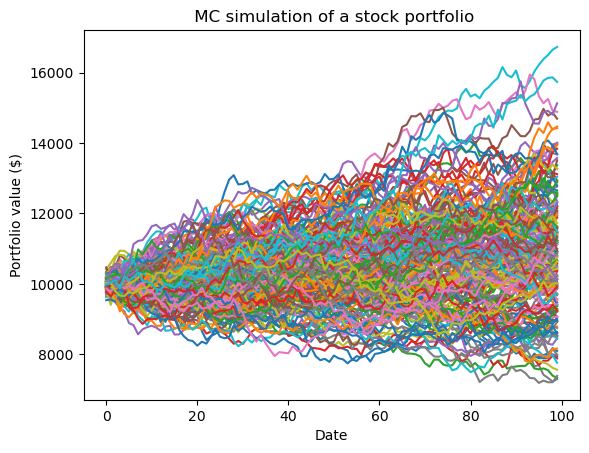

Expected return: 10886.605673553382
Median return: 10875.232351927018
Loss probability: 0.325
VaR (95%): 1837.85
CVaR (95%): 2277.36


In [121]:
# run monte carlo sims , var on my losses 
montecarlosims.monte_carlo(100,Covmatrix,200,meanReturns,config['weigths'],10000)


We wish to find out why the loss probability is so high at 28.5%?

We will try to delve in deeper into understanding how we can reduce our downside

1) Whether the loss probability is driven by systematic risk (interest rate etc)
2) How much unsystematic risk is my portfolio exposed?

Hypothesis: Alot of Tech stocks hence, very little diversification and hence, high unsystematic risk



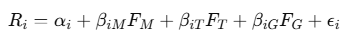

Running of Factor models:

We have decided to run factor models on individual stocks using factors:

- US 500 (market) -> This is market risk encapsulating economy wide shocks, interest rate changes and macro changes
- Tech factor (XLK) -> This is with regards to me being heavy on tech stocks. Hence, we are trying to segregate sector risk from market risk
- HML -> Value vs growth spread. This captures discount rate sensitivity and duration risk 
- SMB -> Size of company. Small cap premium or high business risk


Credits to https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html

for the Fama French daily data


1. Data Cleaning to ensure similar 

- time frames 
- returns

In [125]:
# read csv file in additional data 
ff_data = pd.read_csv("additional data/F-F_Research_Data_Factors_daily.CSV", skiprows=4)
ff_data.rename(columns={'Unnamed: 0':'Date'},inplace=True)
ff_data=ff_data.dropna(axis=0)
ff_data["Date"] = pd.to_datetime(ff_data["Date"], format="%Y%m%d")
ff_data=ff_data[ff_data['Date']>=start].reset_index()
ff_data.drop(0,axis=0,inplace=True)
ff_data.set_index(ff_data['Date'],inplace=True)
ff_data.drop(columns=['Date','index'],inplace=True)
ff_data=ff_data/100
ff_data

,Mkt-RF,SMB,HML,RF
Date,,,,
2021-01-05,0.0086,0.0122,0.0050,0.0000
2021-01-06,0.0079,0.0214,0.0394,0.0000
2021-01-07,0.0176,0.0032,-0.0081,0.0000
2021-01-08,0.0051,-0.0075,-0.0138,0.0000
2021-01-11,-0.0052,0.0026,0.0126,0.0000
...,...,...,...,...
2025-12-24,0.0029,0.0003,0.0001,0.0002
2025-12-26,-0.0006,-0.0032,0.0009,0.0002
2025-12-29,-0.0041,-0.0018,0.0007,0.0002


In [123]:
#get US 500 data and XLK - Tech 
marketdata = yf.download(
    ["SPY", "XLK"],
    start=start,
    end=end,
    auto_adjust=True
)
marketdata=marketdata[['Close']]

marketdata=marketdata.pct_change()
marketdata=marketdata.dropna()
marketdata=marketdata['Close']
marketdata



[*********************100%***********************]  2 of 2 completed


Ticker,SPY,XLK
Date,,
2021-01-05,0.006887,0.006489
2021-01-06,0.005979,-0.017245
2021-01-07,0.014857,0.026954
2021-01-08,0.005698,0.006465
2021-01-11,-0.006741,-0.008259
...,...,...
2025-12-23,0.004570,0.005442
2025-12-24,0.003518,0.002398
2025-12-26,-0.000101,0.001572


In [124]:
stockreturns=returns.dropna()
stockreturns

Ticker,AAPL,ADBE,AVPT,BABA,CRM,DKNG,GOOG,LMT,MSFT,NFLX,NOC,NVDA,PG,PLTR,SOFI,UNH
Date,,,,,,,,,,,,,,,,
2021-01-05,0.012364,0.000721,0.010782,0.055080,0.005492,0.060633,0.007337,0.012041,0.000964,-0.003940,0.006208,0.022210,0.006385,0.052632,-0.004098,-0.013448
2021-01-06,-0.033662,-0.039902,-0.037333,-0.053203,-0.024242,0.029739,-0.003234,-0.002179,-0.025929,-0.038998,0.008598,-0.058953,0.010526,-0.043089,-0.002469,0.041966
2021-01-07,0.034123,0.024512,0.019391,-0.003119,0.008466,0.015818,0.029943,-0.015746,0.028457,0.016784,-0.021929,0.057830,-0.009346,0.062022,0.579208,0.016032
2021-01-08,0.008631,0.015406,-0.006114,0.040943,0.018625,0.044806,0.011168,-0.018829,0.006093,0.002967,-0.014526,-0.005040,-0.000432,0.008000,-0.020899,-0.004493
2021-01-11,-0.023249,-0.022387,0.020506,-0.037343,-0.017069,0.030769,-0.022405,0.004701,-0.009699,-0.022140,0.022231,0.025966,-0.006773,0.028968,0.013340,-0.007265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005130,-0.014292,-0.000734,0.001788,-0.004535,-0.010315,0.013972,-0.002109,0.003980,0.002896,-0.007868,0.030051,0.003434,0.000773,-0.005850,-0.001107
2025-12-24,0.005324,0.001589,-0.002203,-0.007737,0.006947,-0.002316,-0.000032,0.006631,0.002403,0.001497,0.003948,-0.003171,0.009149,0.000206,0.010666,0.008559
2025-12-26,-0.001497,0.002323,0.013245,0.014528,0.003091,0.012188,-0.002249,-0.005600,-0.000635,0.008864,-0.008552,0.010180,0.001730,-0.028120,-0.014920,0.012974


To find the True effect of Tech: 
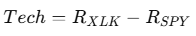

XLK to deduct the overall Market return as they will have significant overlap to reduce multicollinearity

In [130]:
marketdata['Tech']=marketdata['XLK']-marketdata['SPY']
marketdata

Ticker,SPY,XLK,Tech
Date,,,
2021-01-05,0.006887,0.006489,-0.000398
2021-01-06,0.005979,-0.017245,-0.023224
2021-01-07,0.014857,0.026954,0.012097
2021-01-08,0.005698,0.006465,0.000767
2021-01-11,-0.006741,-0.008259,-0.001518
...,...,...,...
2025-12-23,0.004570,0.005442,0.000872
2025-12-24,0.003518,0.002398,-0.001119
2025-12-26,-0.000101,0.001572,0.001673


In [153]:
# aligning all the data

data = stockreturns.join(ff_data, how="inner")
data=data.join(marketdata,how='inner')
data['SPY-RF']=data['SPY']-data['RF']
X=data[['RF','SPY-RF','Tech','HML','SMB']]
data

,AAPL,ADBE,AVPT,BABA,CRM,DKNG,GOOG,LMT,MSFT,NFLX,...,SOFI,UNH,Mkt-RF,SMB,HML,RF,SPY,XLK,Tech,SPY-RF
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.012364,0.000721,0.010782,0.055080,0.005492,0.060633,0.007337,0.012041,0.000964,-0.003940,...,-0.004098,-0.013448,0.0086,0.0122,0.0050,0.0000,0.006887,0.006489,-0.000398,0.006887
2021-01-06,-0.033662,-0.039902,-0.037333,-0.053203,-0.024242,0.029739,-0.003234,-0.002179,-0.025929,-0.038998,...,-0.002469,0.041966,0.0079,0.0214,0.0394,0.0000,0.005979,-0.017245,-0.023224,0.005979
2021-01-07,0.034123,0.024512,0.019391,-0.003119,0.008466,0.015818,0.029943,-0.015746,0.028457,0.016784,...,0.579208,0.016032,0.0176,0.0032,-0.0081,0.0000,0.014857,0.026954,0.012097,0.014857
2021-01-08,0.008631,0.015406,-0.006114,0.040943,0.018625,0.044806,0.011168,-0.018829,0.006093,0.002967,...,-0.020899,-0.004493,0.0051,-0.0075,-0.0138,0.0000,0.005698,0.006465,0.000767,0.005698
2021-01-11,-0.023249,-0.022387,0.020506,-0.037343,-0.017069,0.030769,-0.022405,0.004701,-0.009699,-0.022140,...,0.013340,-0.007265,-0.0052,0.0026,0.0126,0.0000,-0.006741,-0.008259,-0.001518,-0.006741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005130,-0.014292,-0.000734,0.001788,-0.004535,-0.010315,0.013972,-0.002109,0.003980,0.002896,...,-0.005850,-0.001107,0.0032,-0.0094,-0.0020,0.0002,0.004570,0.005442,0.000872,0.004370
2025-12-24,0.005324,0.001589,-0.002203,-0.007737,0.006947,-0.002316,-0.000032,0.006631,0.002403,0.001497,...,0.010666,0.008559,0.0029,0.0003,0.0001,0.0002,0.003518,0.002398,-0.001119,0.003318
2025-12-26,-0.001497,0.002323,0.013245,0.014528,0.003091,0.012188,-0.002249,-0.005600,-0.000635,0.008864,...,-0.014920,0.012974,-0.0006,-0.0032,0.0009,0.0002,-0.000101,0.001572,0.001673,-0.000301


In [168]:
summaryoffactormodel,results=factor_models.factor_modelling(stockreturns,X)
summaryoffactormodel


===== AAPL =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     510.7
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          6.53e-261
Time:                        14:00:20   Log-Likelihood:                 3895.0
No. Observations:                1253   AIC:                            -7780.
Df Residuals:                    1248   BIC:                            -7754.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.809e-05      0.000  

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,R2,N
Ticker,,,,,,,
AAPL,0.000038,1.048312,0.528717,-0.096364,-0.109100,0.620783,1253
ADBE,-0.000602,1.010306,0.472685,-0.413423,-0.030338,0.457378,1253
AVPT,0.000200,0.910151,-0.002130,-0.543626,1.012448,0.289959,1253
BABA,-0.000058,0.837273,-0.166500,-0.441258,0.562360,0.142695,1253
CRM,-0.000132,1.030044,0.343090,-0.363345,0.221568,0.440902,1253
DKNG,0.000384,1.436771,-0.436507,-0.876546,1.429658,0.347300,1253
GOOG,0.000642,1.154963,-0.016615,-0.427549,-0.129906,0.514696,1253
LMT,0.000147,0.503494,-0.550638,0.109756,-0.200831,0.125059,1253
MSFT,0.000128,0.894473,0.668021,-0.241055,-0.272304,0.704370,1253


Total Portfolio Exposure 

In [ ]:
portfolio_return = (stockreturns @ config['weigths']) #@ is a matrix multiplication 
y = portfolio_return - ff_data['RF']

In [172]:
portfolio_return=pd.DataFrame(y).dropna()
portfolio_return.rename(columns={0:'Portfolio'},inplace=True)
portfolio_exposure,full_results=factor_models.factor_modelling(portfolio_return,X)
portfolio_exposure


===== Portfolio =====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1479.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:02:47   Log-Likelihood:                 4532.1
No. Observations:                1253   AIC:                            -9054.
Df Residuals:                    1248   BIC:                            -9028.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.

,Alpha,Beta_Mkt,Beta_Tech,Beta_HML,Beta_SMB,R2,N
Ticker,,,,,,,
Portfolio,0.000105,1.045988,0.24183,-0.30315,0.237819,0.825842,1253


What does this tell us about my portfolio exposure:

1) Firstly looking at adjusted R^2, systematic and sector risk can explain 82.5% of my portfolio - the rest being (unsystematic risk+unmodelled systematic risk)

2) Durbin watson == close to 2:
- No autocorrelation of residuals is involved

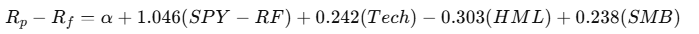
3) All factors have a significant effect in explaining the risk of my portfolio, with t stat for all 4 factors >1.96 at 5% significance level.

Individual factors:
- Positive Beta to market. If market goes up 1 percent, my portfolio goes up 1.04%. 
- Tech leaning due to a positive Beta for Beta_tech
- Negative HML: Portfolio moves when 'value' stock perception increases
- Positive SMB: Smaller cap stocks in portfolio contribute positively to portfolio return
